In this notebook, the results from the reactio-diffusion-advection system in two dimensions from Hiroshi Serizawa, Takashi Amemiya, and Kiminori Itoh. “Patchiness in a minimal
nutrient—phytoplankton model”. In: Journal of Biosciences 33.3 (2008), pp. 391–403. will be replicated.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

/home/alonso/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
'''Function that implements the instantaneous rate of change for the nutrient availability with dimensionless variables'''
def dn(n, p, i_n, a, m_n, f_p):

    return i_n - a*n/(1 + n)*p - m_n*n

In [3]:
'''Function that implements the instantaneous rate of change of the dimensionless phytoplankton density'''
def dp(n, p, i_n, a, m_n, f_p):
    
    return n/(1 + n)*p - f_p*p/(1 + p)

In [4]:
def discretized_laplacian_atharva(grid, h):
   
    # 2nd order centered finite difference approximation on the boundary of the grid:
    del2_surr = (grid[2:, 1:-1] + grid[:-2, 1:-1] + grid[1:-1, 2:] + \
                 grid[1:-1, :-2] - 4 * grid[1:-1, 1:-1]) / h**2
    
    del2 = np.zeros_like(grid)
    del2[1:-1, 1:-1] = del2_surr.copy()
    
    # 4th order centered finite difference approximation in the middle of the grid:
    del2_middle = (-grid[4:, 2:-2] + 16 * grid[3:-1, 2:-2] - \
                   30 * grid[2:-2, 2:-2] + 16 * grid[1:-3, 2:-2] - \
                   grid[:-4, 2:-2]) / (12 * h**2) + \
                  (-grid[2:-2, 4:] + 16 * grid[2:-2, 3:-1] - \
                   30 * grid[2:-2, 2:-2] + 16 * grid[2:-2, 1:-3] - \
                   grid[2:-2, :-4]) / (12 * h**2)
    
    del2[2:-2, 2:-2] = del2_middle

    return del2

In [5]:
def discrete_laplacian(X, h):

    x = X.copy()
    
    x = (-np.roll(X,-2,axis = 0) + 16 * np.roll(X,-1,axis = 0) - 30 * X + 16 * np.roll(X,1,axis = 0) - np.roll(X,2,axis = 0) - 
            np.roll(X,-2,axis = 1) + 16 * np.roll(X,-1,axis = 1) - 30 * X + 16 * np.roll(X,1,axis = 1) - np.roll(X,2,axis = 1)) / (12*h**2)

    return x

In [6]:
def discretized_divergence_atharva(X, h, phi_x, phi_y):

    # 2nd order centered difference formula on the boundary:
    div_surr = ((X[2:, 1:-1] - X[:-2, 1:-1]) / (2 * h)) * phi_x[1:-1, 1:-1] + \
                ((X[1:-1, 2:] - X[1:-1, :-2]) / (2 * h)) * phi_y[1:-1, 1:-1]

    div = np.zeros_like(X)
    div[1:-1, 1:-1] = div_surr.copy()

    # 4th order centered difference formula in the middle:
    div_middle = ((X[:-4, 2:-2] - 8 * X[1:-3, 2:-2] + \
                    8 * X[3:-1, 2:-2] - X[4:, 2:-2]) / \
                    (12 * h)) * phi_x[1:-1, 1:-1] + \
                  ((X[2:-2, 4:] - 8 * X[2:-2, 1:-3] + \
                    8 * X[2:-2, 3:-1] - X[2:-2, 4:]) / \
                    (12 * h)) * phi_y[1:-1, 1:-1]

    return div

In [7]:
def discretized_divergence(X, h, phi_x, phi_y):

    # 4th order centered difference formula
    div = ((np.roll(X,-2,axis = 0) - 8 * np.roll(X,-1,axis = 0) + \
                    8 * np.roll(X,1,axis = 0) - np.roll(X,2,axis = 0)) / \
                    (12 * h)) * phi_x + \
                  ((np.roll(X,-2,axis = 1) - 8 * np.roll(X,-1,axis = 1) + \
                    8 * np.roll(X,1,axis = 1) - np.roll(X,2,axis = 1)) / \
                    (12 * h)) * phi_y

    return div

In [8]:
def initial_conditions(X, n1, p1, A, L):

    nrows, ncols = X.shape

    n, p = np.zeros_like(X), np.zeros_like(X)

    for i in range(nrows):

        n[i, :] += n1 * (1 + A * np.sin((np.pi / L) * np.arange(ncols)))

    for j in range(ncols):
    
        p[:, j] += p1 * (1 + A * np.sin((np.pi / L) * np.arange(nrows)))

    return n, p

In [ ]:
def stream(X, x_centres, y_centres, r_0, s, sigma):

    nrows, ncols = X.shape
    phi = np.zeros_like(X)
    n_eddies = x_centres.size

    for i in range(nrows):
        for j in range(ncols):

            for k in range(n_eddies):

                phi[i,j] += sigma[k] * np.exp(-((i - x_centres[k])**2 + (j - y_centres[k])**2) / r_0**2)

    phi *= s

    return phi

In [18]:
# Set 1
n_0 = 5
p_0 = 0.2
i_n = 0.9
a = 8
m_n = 0.03
f_p = 0.9
d = 0.04
nu_max = 0.3
r_0 = 10
n_eddies = 100
L = 100
A = 0.25
T = 1000
dt = 0.12
N = 180
s =1

In [11]:
np.arange(4)

array([0, 1, 2, 3])

In [13]:
np.random.seed(26)

In [32]:
gen = np.random.default_rng(seed = 26)

x_centres = gen.uniform(0, 2 * L, size = n_eddies)
y_centres = gen.uniform(0, 2 * L, size = n_eddies)

In [37]:
sigma = np.repeat([1,-1],[50,50])
X = np.ones((200,200))

In [ ]:
vel = stream(X, x_centres, y_centres, r_0, s, sigma)

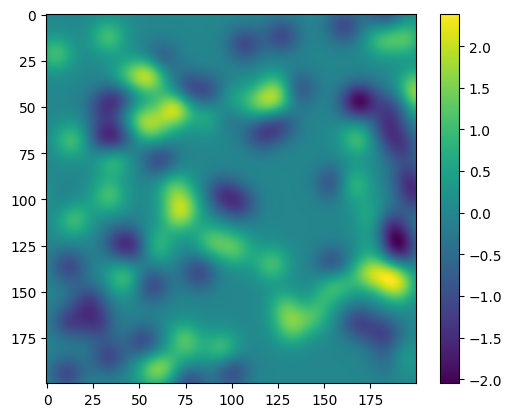

In [41]:
plt.imshow(vel)
plt.colorbar()
plt.show()